<a href="https://colab.research.google.com/github/SkyFlowTraveler/TitanicSurvival-classification/blob/main/TitanicModelsAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

plt.style.use('fivethirtyeight')
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['Survived'], axis = 1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)


#train = pd.concat([X_train, y_train], axis = 1)
train = df
test = pd.concat([X_test, y_test], axis = 1)

train.shape

(891, 12)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
X_train.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,140
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,553


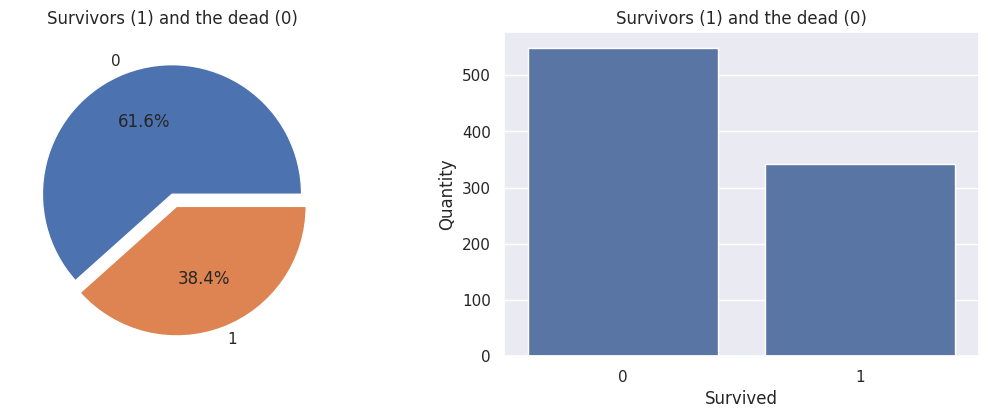

In [ ]:
f, ax = plt.subplots(1, 2, figsize = (12,4))
train['Survived'].value_counts().plot.pie(
    explode = [0, 0.1], autopct = '%1.1f%%', ax = ax[0], shadow = False)
ax[0].set_title('Survivors (1) and the dead (0)')
ax[0].set_ylabel('')
sns.countplot(x = 'Survived', data = train, ax = ax[1])
ax[1].set_ylabel('Quantity')
ax[1].set_title('Survivors (1) and the dead (0)')
plt.show()

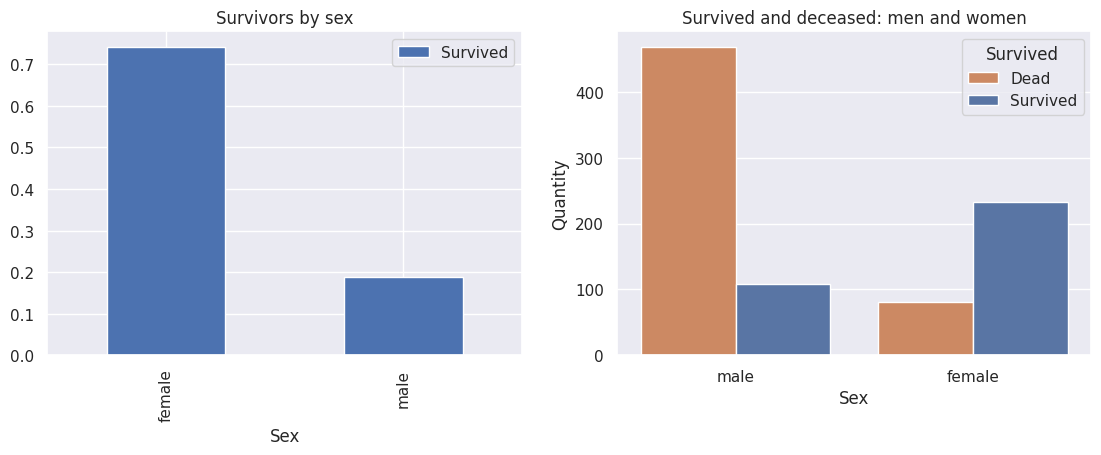

In [ ]:
f, ax = plt.subplots(1, 2, figsize = (12,4))
colors = sns.color_palette('deep')
train[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax = ax[0],
                                                            color = colors[0])
ax[0].set_title('Survivors by sex')
sns.countplot(x = 'Sex', hue = 'Survived', hue_order = [0,1],
              data = train, ax = ax[1],
              palette = [colors[1],colors[0]])
ax[1].set_ylabel('Quantity')
ax[1].legend(title = 'Survived', labels = ['Dead', 'Survived'])
ax[1].set_title('Survived and deceased: men and women')
plt.show()

In [ ]:
train = train.drop(['Cabin', 'Ticket'], axis = 1)
test = test.drop(['Cabin','Ticket'], axis = 1)
train.fillna({'Embarked':'S'})

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


In [ ]:
#from sklearn.impute import SimpleImputer

#imputer = SimpleImputer(strategy = 'most_frequent')

#train[['Embarked']]= imputer.fit_transform(train[['Embarked']])

#Забраковано по причине нецелесообразности. В Pipeline ещё ладно, но это!

In [ ]:
train['Age'] = train['Age'].fillna(-0.5)
test['Age'] = test['Age'].fillna(-0.5)
bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager',
          'Student', 'Young Adult', 'Adult', 'Senior']
train['AgeGroup']=pd.cut(train['Age'], bins, labels = labels)
test['AgeGroup']=pd.cut(test['Age'], bins, labels = labels)

In [ ]:
unitedlist = [train, test]

for dataset in unitedlist:
  dataset['Title']= dataset.Name.str.extract(' ([A-Za-z]+)\.')
  print(dataset['Title'].unique())

pd.crosstab(train['Title'],train['Sex'])

for dataset in unitedlist:
  dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col','Don','Dr',
                                               'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')

  dataset['Title']= dataset['Title'].replace(
      ['Countess', 'Lady', 'Sir'], 'Royal')
  dataset['Title']= dataset['Title'].replace('Mile','Miss')
  dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
  dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

train[['Title', 'Survived']].groupby(['Title'], as_index = False).mean()

title_mapping = {'Mr': 1, 'Miss': 2, 'Mrs': 3,
                 'Master': 4, 'Royal':5, 'Rare':6}

for dataset in unitedlist:
  dataset['Title'] = dataset['Title'].map(title_mapping)
  dataset['Title'] = dataset['Title'].fillna(0)

train

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'Countess' 'Jonkheer']
['Master' 'Mr' 'Miss' 'Rev' 'Don' 'Mrs' 'Jonkheer' 'Dr' 'Sir']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Student,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Adult,3.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Young Adult,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Young Adult,3.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Young Adult,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,Young Adult,6.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,Student,2.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,-0.5,1,2,23.4500,S,Unknown,2.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,Young Adult,1.0


In [ ]:
mr_age = train.loc[train['Title']==1, 'AgeGroup'].mode()[0] #Young Adult Мистер
miss_age = train.loc[(train['Title']==2) & (train['AgeGroup']!='Unknown'),'AgeGroup'].mode()[0] #Student Барышня
mrs_age = train.loc[train['Title']==3,'AgeGroup'].mode()[0] #Adult Замужняя
master_age = train.loc[train['Title']==4,'AgeGroup'].mode()[0] #Baby Мальчик до 12(обычно) - 18 лет
royal_age = train.loc[train['Title']==5,'AgeGroup'].mode()[0] #Adult
rare_age = train.loc[train['Title']==6,'AgeGroup'].mode()[0]  #Adult


age_title_mapping = {1: mr_age, 2: miss_age,
                     3: mrs_age, 4:master_age, 5: royal_age, 6: rare_age}

mask = train['AgeGroup'] == 'Unknown'
train.loc[mask, 'AgeGroup'] = train.loc[mask, 'Title'].map(age_title_mapping)
test.loc[mask, 'AgeGroup'] = test.loc[mask, 'Title'].map(age_title_mapping)

#train.loc[mask, 'AgeGroup'] = train.loc[mask, 'Title'].map(age_title_mapping)
  #train[mask][x]=train[mask][x].map(age_title_mapping)

In [ ]:
age_mapping = {'Baby':1, 'Child':2, 'Teenager': 3, 'Student': 4, 'Young Adult':5, 'Adult': 6, 'Senior':7}

train['AgeGroup'] = train['AgeGroup'].map(age_mapping)
test['AgeGroup'] = test['AgeGroup'].map(age_mapping)

train.head()

train = train.drop(['Age', 'Name'], axis = 1)
test = test.drop(['Age', 'Name'], axis = 1)

In [ ]:
sex_mapping = {'male':1,'female':-1} #Здесь хочу здесь OneHotEncoding через pd.get_dummies()
train['Sex'] = train['Sex'].map(sex_mapping)
test['Sex'] = test['Sex'].map(sex_mapping)

embarked_mapping = {'S': 1, 'C':2, 'Q':3}
train['Embarked'] = train['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)

In [ ]:
train['Fare'] = train['Fare'].fillna(train.groupby('Pclass')['Fare'].transform('mean'))

train['FareBand'] = pd.qcut(train['Fare'], 4, labels = [1,2,3,4])
test['FareBand'] = pd.qcut(test['Fare'], 4, labels = [1,2,3,4])

train = train.drop(['PassengerId','Fare'], axis = 1)
test = test.drop(['PassengerId','Fare'], axis = 1)

train['FareBand'] = train['FareBand'].astype(int)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = train.drop(['Survived'], axis = 1)
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.fit_transform(X_test)

In [ ]:
X_train

,Pclass,Sex,SibSp,Parch,Embarked,AgeGroup,Title,FareBand
331,1,1,0,0,1.0,6.0,1.0,3
733,2,1,0,0,1.0,4.0,1.0,2
382,3,1,0,0,1.0,5.0,1.0,2
704,3,1,1,0,1.0,5.0,1.0,1
813,3,-1,4,2,1.0,2.0,2.0,4
...,...,...,...,...,...,...,...,...
106,3,-1,0,0,1.0,4.0,2.0,1
270,1,1,0,0,1.0,5.0,1.0,3
860,3,1,2,0,1.0,6.0,1.0,2
435,1,-1,1,2,1.0,3.0,2.0,4


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
'''
param_grid = (
    {'n_estimators': [3, 10, 30], 'max_features':[2,4,6,8,10,np.inf]}
)

gridsearch = GridSearchCV(RandomForestClassifier(), param_grid,
                          scoring = 'neg_mean_squared_error', return_train_score = True)
gridsearch.fit(X_train, y_train)
'''
#randforest = gridsearch.best_estimator_
randforest = RandomForestClassifier()

randforest.fit(X_train, y_train)
prediction = randforest.predict(X_test)

acc_randforest = accuracy_score(prediction, y_test)
acc_randforest

0.8268156424581006

In [ ]:
# Или конкретно по Embarked
X_train['Embarked'].fillna(1, inplace = True)

print(y_train.isnull().sum())

0


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    int64  
 2   SibSp     712 non-null    int64  
 3   Parch     712 non-null    int64  
 4   Embarked  712 non-null    float64
 5   AgeGroup  712 non-null    float64
 6   Title     712 non-null    float64
 7   FareBand  712 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 50.1 KB


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

gbm = GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1,
                                 max_depth = 20, min_samples_leaf = 10, random_state = 42)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)
print('GBM Accuracy:', accuracy_score(y_pred_gbm, y_test))

#============================================================

xgb = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 20, min_samples_leaf = 10, use_label_encoder = False, eval_metric = 'logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('XGB Accuracy:', accuracy_score(y_pred_xgb, y_test))

#============================================================

lgbm = LGBMClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 20, min_samples_leaf = 10, random_state =42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
print('LightGBM Accuracy:', accuracy_score(y_test, y_pred_lgbm))

GBM Accuracy: 0.8379888268156425
XGB Accuracy: 0.8379888268156425
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=10. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=10. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 44
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overr